## LangGraph
It Mainly contains 4 Blocks
1. **State** : is a dictionary used to store Data among all nodes
- ex: Kind of vehicle
2. **Nodes** are simply containers to execute specific task
- ex: Buldings or diffrent Locations
3. **Edges**: It is used to connect every node in state
- ex: Roads connect diffrent Locations

4. **Graph** : It is a object acts as blue print or layout to add Nodes, Define edges

In [1]:
pip install typing


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26304 sha256=fb7f53d03a01c7a34987efc00bd307a29fe03d5b1a01a10a23e1f25ab65db9c7
  Stored in directory: /root/.cache/pip/wheels/12/98/52/2bffe242a9a487f00886e43b8ed8dac46456702e11a0d6abef
Successfully built typing


Creating a state

In [1]:
# State Generation
from typing import TypedDict

In [2]:
class StateVar(TypedDict):
  Var :str

Creating nodes

In [13]:
def Node1(StateVar):
  StateVar['Var']=StateVar['Var'].upper()
  return StateVar  #very node must return a dictionary (State), not a string.

Creating graph

In [14]:
from langgraph.graph import StateGraph, START, END

In [15]:
graph=StateGraph(StateVar)

Adding Nodes

In [16]:
graph.add_node('N1', Node1)

Adding Edges

In [17]:
graph.add_edge(START, 'N1')
graph.add_edge( 'N1', END)

### WHen ever Value error occurs try to update LanGraph Package and Restart Session and rerun all the codes
Compile

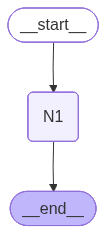

In [18]:
Gvar=graph.compile()
Gvar

In [19]:
Gvar.invoke({
    'Var':'Chidvilas'
})

{'Var': 'CHIDVILAS'}

## Conditional Nodes

In [20]:
from typing import TypedDict

In [21]:
class state(TypedDict):
  Age: int

In [32]:
def check(state:state ):
  print(" Welcome to RADX, Checking the Weather......")
  return state

In [23]:
def rainnode(state:state ):
  print("Yes , we wet together")
  return state

def drynodes(state:state ):
  print("We can eat the ICECREAM")
  return state

In [28]:
import random
def Condition(state:state ):
  return random.random()>=0.5

In [30]:
# Graph
from langgraph.graph import START, END, StateGraph

In [31]:
graph=StateGraph(state)

In [33]:
graph.add_node( 'Check', check)
graph.add_node('rainnode', rainnode )
graph.add_node( 'drynodes',drynodes )
graph.add_node( 'Condition', Condition)


In [38]:
graph.add_edge(START, 'Check')
graph.add_conditional_edges('Check', Condition,{
    True: "rainnode",
    False:"drynodes"
})
graph.add_edge("rainnode", END)
graph.add_edge("drynodes", END)

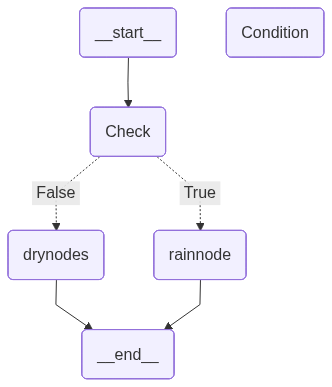

In [39]:
graphvar=graph.compile()
graphvar

In [42]:
graphvar.invoke({
    "Age": ""
})

 Welcome to RADX, Checking the Weather......
Yes , we wet together


{'Age': ''}